
# Phenomenon 6 Analysis: Initial State and Baseline Heterogeneity

This notebook analyzes whether pre-experiment self-reported stress is associated with different physiological patterns during the **initial meditation**, whether that baseline state carries over into later tasks, and whether differences persist or converge by the **final meditation**.

## Research question

Does the subgroup that arrived already somewhat stressed show a different baseline during the initial meditation, and could that baseline heterogeneity distort later comparisons?

## Planned analyses

1. **Characterize initial meditation by baseline stress group**
   - Split participants by pre-experiment self-reported stress.
   - Compare initial-meditation physiology across groups.

2. **Test persistence into later tasks**
   - Correlate baseline stress with:
     - maximum EDA during the emotional video
     - self-reported mathematics demand proxy

3. **Compare initial vs final meditation**
   - Test whether initially stressed participants converge toward the non-stressed group or whether differences remain.

4. **Assess whether baseline normalization changes the conclusions**
   - This addresses the concern that a single raw comparison might be confounded by heterogeneous starting points.


## Interpretation rule

A significant difference during the initial meditation suggests **baseline heterogeneity**.  
If raw later-task differences disappear after within-participant normalization, that supports the idea that **baseline adjustment is necessary** and that a one-size-fits-all raw comparison may be misleading.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True

DATA_PATH = "../NPFC-Test_Database_V2.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head(3)


Shape: (47905, 66)
Columns: 66


,Subject_ID,Timestamp,Test_Time,Task_Num,Task_Time,Task_Type,Frame,Task_Frame,Selfreport_valence,Selfreport_arousal,...,Dominant_Hand,Average_Sleep,Sleep_Last_Night,Perceived_Tiredness,Perceived_Stress,Substance_Use_8h,Neurological_Condition,Cardiac_Condition,Wearing_Glasses,Highest_Education_Level
0,IFE-EC-NPFC-T003-00,07/03/2023 10:36,00:00:01,1.1,00:00:01,0,0,0,0,0,...,Right,Between 6 and 7 hours,Between 6 and 7 hours,Slightly tired,Not stressed,No,No,No,Yes,NaN
1,IFE-EC-NPFC-T003-00,07/03/2023 10:36,00:00:02,1.1,00:00:02,0,30,30,0,0,...,Right,Between 6 and 7 hours,Between 6 and 7 hours,Slightly tired,Not stressed,No,No,No,Yes,NaN
2,IFE-EC-NPFC-T003-00,07/03/2023 10:36,00:00:03,1.1,00:00:03,0,60,60,0,0,...,Right,Between 6 and 7 hours,Between 6 and 7 hours,Slightly tired,Not stressed,No,No,No,Yes,NaN



## 1. Build participant-level baseline stress groups

The dataset includes `Perceived_Stress`, which is treated here as the **pre-experiment self-report of stress**.  
Two versions are used:

- **Ordinal 4-level stress score**:
  - Not stressed = 0
  - Slightly stressed = 1
  - Moderately stressed = 2
  - Very stressed = 3

- **Primary binary grouping for baseline comparisons**:
  - Not stressed
  - Any pre-experiment stress

The binary grouping is useful because some categories are small, especially the "Very stressed" category.


In [2]:

stress_order = {
    "Not stressed": 0,
    "Slightly stressed": 1,
    "Moderately stressed": 2,
    "Very stressed": 3,
}

participant_stress = (
    df.groupby("Subject_ID")["Perceived_Stress"]
      .agg(lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan)
      .rename("Perceived_Stress")
      .to_frame()
)

participant_stress["stress_score"] = participant_stress["Perceived_Stress"].map(stress_order)
participant_stress["stress_binary"] = np.where(
    participant_stress["stress_score"] > 0,
    "Any pre-experiment stress",
    "Not stressed"
)

counts = participant_stress["Perceived_Stress"].value_counts().sort_index()
counts


Perceived_Stress
Moderately stressed     7
Not stressed           15
Slightly stressed      18
Very stressed           1
Name: count, dtype: int64

In [3]:

# Percentages by pre-experiment stress category
pct = (counts / counts.sum() * 100).round(1).rename("Percent")
pd.concat([counts.rename("Count"), pct], axis=1)


,Count,Percent
Perceived_Stress,,
Moderately stressed,7,17.1
Not stressed,15,36.6
Slightly stressed,18,43.9
Very stressed,1,2.4



## 2. Create task-level physiological summaries

For physiology during each task segment, this notebook computes participant-level summaries:

- **EDA mean**, **EDA median**, **EDA max**
- **Alpha mean** using the average across:
  - `Alpha_TP9`
  - `Alpha_AF7`
  - `Alpha_AF8`
  - `Alpha_TP10`
- **BVP mean** as an exploratory proxy only

These are computed separately for:

- initial meditation (**2.1**)
- emotional video (**6.1**)
- final meditation (**8.1**)

For self-report tasks, the repeated rows within a self-report segment are collapsed to participant-level means.


In [4]:

alpha_cols = ["Alpha_TP9", "Alpha_AF7", "Alpha_AF8", "Alpha_TP10"]

def summarize_physiology(task_num):
    sub = df[df["Task_Num"] == task_num].copy()
    sub["Alpha_mean_row"] = sub[alpha_cols].mean(axis=1)
    out = (
        sub.groupby("Subject_ID")
           .agg(
               EDA_mean=("EDA", "mean"),
               EDA_median=("EDA", "median"),
               EDA_max=("EDA", "max"),
               Alpha_mean=("Alpha_mean_row", "mean"),
               Alpha_median=("Alpha_mean_row", "median"),
               BVP_mean=("BVP", "mean"),
               seconds=("Task_Time", "count"),
           )
    )
    return out

def summarize_self_report(task_num, prefix):
    sub = df[df["Task_Num"] == task_num].copy()
    out = (
        sub.groupby("Subject_ID")
           .agg(
               **{
                   f"{prefix}_valence": ("Selfreport_valence", lambda x: x.replace(0, np.nan).mean()),
                   f"{prefix}_arousal": ("Selfreport_arousal", lambda x: x.replace(0, np.nan).mean()),
                   f"{prefix}_focus": ("Selfreport_focus", lambda x: x.replace(0, np.nan).mean()),
               }
           )
    )
    return out

initial_meditation = summarize_physiology(2.1).add_prefix("init_")
emotional_video = summarize_physiology(6.1).add_prefix("emo_")
final_meditation = summarize_physiology(8.1).add_prefix("final_")

math_self = summarize_self_report(3.2, "math")
initial_self = summarize_self_report(2.2, "initial")
final_self = summarize_self_report(8.2, "finalself")

subject = (
    participant_stress
    .join(initial_meditation)
    .join(emotional_video)
    .join(final_meditation)
    .join(math_self)
    .join(initial_self)
    .join(final_self)
)

subject.shape


(41, 33)

In [6]:

subject.head()


,Perceived_Stress,stress_score,stress_binary,init_EDA_mean,init_EDA_median,init_EDA_max,init_Alpha_mean,init_Alpha_median,init_BVP_mean,init_seconds,emo_EDA_mean,emo_EDA_median,emo_EDA_max,emo_Alpha_mean,emo_Alpha_median,emo_BVP_mean,emo_seconds,final_EDA_mean,final_EDA_median,final_EDA_max,final_Alpha_mean,final_Alpha_median,final_BVP_mean,final_seconds,math_valence,math_arousal,math_focus,initial_valence,initial_arousal,initial_focus,finalself_valence,finalself_arousal,finalself_focus
Subject_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
IFE-EC-NPFC-T003-00,Not stressed,0,Not stressed,0.094605,0.094788,0.096802,0.593181,0.587766,0.000019,146,0.103142,0.102951,0.117316,0.522563,0.521222,0.000002,181,0.112247,0.112256,0.115066,0.527308,0.528588,0.000071,121,4.0,3.0,3.0,4.0,4.0,2.0,4.0,4.0,4.0
IFE-EC-NPFC-T003-01,Slightly stressed,1,Any pre-experiment stress,0.152945,0.143547,0.249619,0.659343,0.657576,0.000018,146,0.029705,0.028576,0.046801,0.520662,0.507290,0.000037,181,NaN,NaN,NaN,0.659182,0.676375,NaN,121,4.0,5.0,4.0,3.0,3.0,3.0,5.0,4.0,5.0
IFE-EC-NPFC-T003-02,Not stressed,0,Not stressed,2.811222,2.805891,3.254388,0.714872,0.786014,-0.000047,146,1.580569,1.551342,1.939253,0.602651,0.607897,0.000260,181,1.586352,1.549728,2.064224,0.969408,0.972509,0.000036,122,4.0,4.0,4.0,2.0,4.0,2.0,3.0,2.0,3.0
IFE-EC-NPFC-T003-03,Slightly stressed,1,Any pre-experiment stress,0.437479,0.423635,0.582106,0.498902,0.480863,-0.000003,146,0.297692,0.292745,0.389475,0.529105,0.537289,0.000071,181,0.460275,0.430227,0.697414,0.547157,0.560597,0.000110,121,3.0,1.0,4.0,4.0,3.0,2.0,4.0,3.0,3.0
IFE-EC-NPFC-T003-04,Not stressed,0,Not stressed,0.157372,0.117187,0.469174,0.517006,0.507281,-0.000035,146,0.830852,0.817192,0.999034,0.474785,0.477639,-0.000016,181,2.591590,2.541959,3.136541,0.518450,0.503875,0.000036,121,3.0,1.0,5.0,3.0,4.0,2.0,1.0,4.0,4.0



## 3. Descriptive overview of the key variables


In [5]:

desc_cols = [
    "init_EDA_mean", "init_Alpha_mean", "init_BVP_mean",
    "emo_EDA_max", "math_arousal", "math_focus",
    "final_EDA_mean", "final_Alpha_mean", "final_BVP_mean"
]
subject[desc_cols].describe().round(3)


,init_EDA_mean,init_Alpha_mean,init_BVP_mean,emo_EDA_max,math_arousal,math_focus,final_EDA_mean,final_Alpha_mean,final_BVP_mean
count,41.000,40.000,41.000,40.000,39.000,40.000,39.000,40.000,39.000
mean,0.752,0.561,0.000,0.799,2.949,4.275,1.055,0.584,-0.000
std,1.479,0.144,0.000,1.434,1.213,0.716,1.914,0.241,0.000
min,0.028,0.251,-0.000,0.037,1.000,2.000,0.039,-0.427,-0.001
25%,0.057,0.462,-0.000,0.064,2.000,4.000,0.077,0.512,-0.000
50%,0.153,0.562,0.000,0.137,3.000,4.000,0.140,0.589,0.000
75%,0.462,0.643,0.000,0.556,4.000,5.000,1.197,0.695,0.000
max,5.989,0.848,0.001,5.734,5.000,5.000,9.454,0.969,0.001



## 4. Initial meditation: do baseline stress groups differ?

Primary comparison:

- **Not stressed**
- **Any pre-experiment stress**

Statistical test: **Mann-Whitney U**, because the sample is small and the distributions are not guaranteed to be normal.

### Hypothesis

If the initially stressed participants already differ during **2.1 Initial meditation**, then the baseline is not homogeneous and later raw task comparisons may be confounded.


In [8]:

def mannwhitney_summary(df_subject, metric, group_col="stress_binary", g1="Not stressed", g2="Any pre-experiment stress"):
    x = df_subject.loc[df_subject[group_col] == g1, metric].dropna()
    y = df_subject.loc[df_subject[group_col] == g2, metric].dropna()
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    return pd.Series({
        "group1": g1,
        "group2": g2,
        "n_group1": len(x),
        "n_group2": len(y),
        "mean_group1": x.mean(),
        "median_group1": x.median(),
        "mean_group2": y.mean(),
        "median_group2": y.median(),
        "U": stat,
        "p_value": p,
    })

baseline_tests = pd.DataFrame({
    "Initial meditation EDA mean": mannwhitney_summary(subject, "init_EDA_mean"),
    "Initial meditation Alpha mean": mannwhitney_summary(subject, "init_Alpha_mean"),
    "Initial meditation BVP mean (exploratory)": mannwhitney_summary(subject, "init_BVP_mean"),
}).T

baseline_tests.round(4)


,group1,group2,n_group1,n_group2,mean_group1,median_group1,mean_group2,median_group2,U,p_value
Initial meditation EDA mean,Not stressed,Any pre-experiment stress,15,26,1.268657,0.440206,0.453168,0.084285,298.0,0.005532
Initial meditation Alpha mean,Not stressed,Any pre-experiment stress,15,25,0.578869,0.593181,0.550512,0.55426,219.0,0.386461
Initial meditation BVP mean (exploratory),Not stressed,Any pre-experiment stress,15,26,0.000044,0.000008,0.000007,0.000002,205.0,0.797076


In [9]:

# Also show the four-level descriptive table for transparency
subject.groupby("Perceived_Stress")[["init_EDA_mean", "init_Alpha_mean", "init_BVP_mean"]].agg(["count", "mean", "median"]).round(4)


init_EDA_mean                  ... init_BVP_mean            
                            count    mean  median  ...         count mean median
Perceived_Stress                                   ...                          
Moderately stressed             7  0.3575  0.1837  ...             7  0.0    0.0
Not stressed                   15  1.2687  0.4402  ...            15  0.0    0.0
Slightly stressed              18  0.5134  0.0597  ...            18  0.0    0.0
Very stressed                   1  0.0384  0.0384  ...             1 -0.0   -0.0

[4 rows x 9 columns]

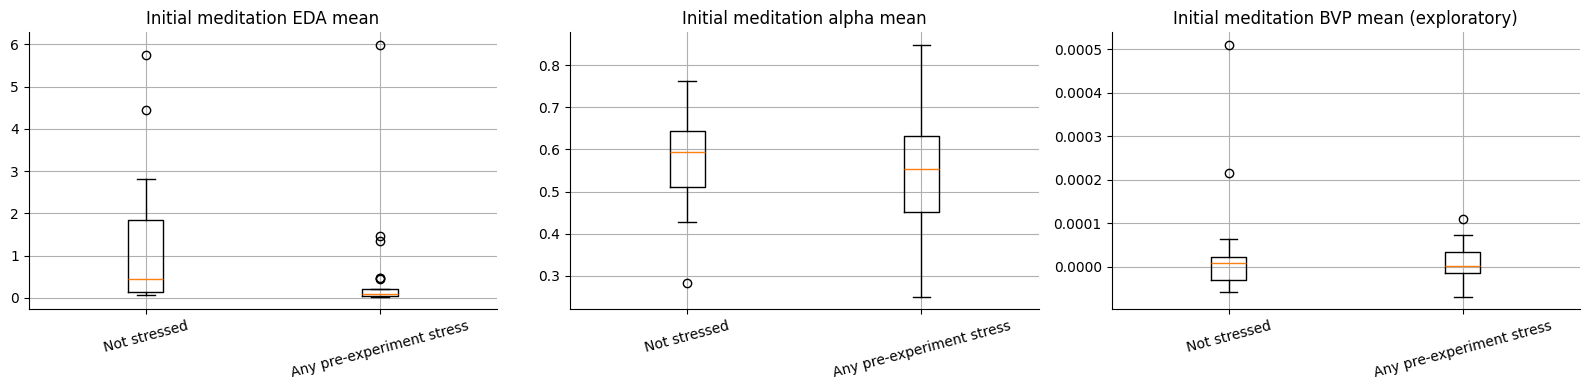

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_specs = [
    ("init_EDA_mean", "Initial meditation EDA mean"),
    ("init_Alpha_mean", "Initial meditation alpha mean"),
    ("init_BVP_mean", "Initial meditation BVP mean (exploratory)"),
]

groups = ["Not stressed", "Any pre-experiment stress"]

for ax, (metric, title) in zip(axes, plot_specs):
    data_to_plot = [subject.loc[subject["stress_binary"] == g, metric].dropna().values for g in groups]
    ax.boxplot(data_to_plot, labels=groups)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()



### Interpretation of the baseline comparison

A significant group difference during **initial meditation** indicates that participants did **not** begin from the same physiological state.  
That is exactly the kind of baseline heterogeneity that can contaminate raw cross-participant comparisons later in the protocol.



## 5. Persistence: does initial stress predict later responses?

Two associations are tested with **Spearman correlation**:

1. **Initial stress score** vs **maximum EDA during the emotional video**
2. **Initial stress score** vs **mathematics self-report demand proxy**

### Note on the mathematics self-report

The file does **not** contain a direct variable called *demand*.  
The closest available option is **self-reported arousal** during the mathematics self-report segment (**3.2**), used here as the **primary proxy** for perceived task demand or activation.  
A supplementary analysis with **focus** is also shown.


In [11]:

def spearman_summary(x, y, label):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    rho, p = spearmanr(valid["x"], valid["y"])
    return pd.Series({"n": len(valid), "spearman_rho": rho, "p_value": p}, name=label)

corr_results = pd.concat([
    spearman_summary(subject["stress_score"], subject["emo_EDA_max"], "Stress score vs emotional-video max EDA"),
    spearman_summary(subject["stress_score"], subject["math_arousal"], "Stress score vs math self-report arousal"),
    spearman_summary(subject["stress_score"], subject["math_focus"], "Stress score vs math self-report focus"),
], axis=1).T

corr_results.round(4)


,n,spearman_rho,p_value
Stress score vs emotional-video max EDA,40.0,-0.3973,0.0111
Stress score vs math self-report arousal,39.0,0.0806,0.6255
Stress score vs math self-report focus,40.0,0.2374,0.1402


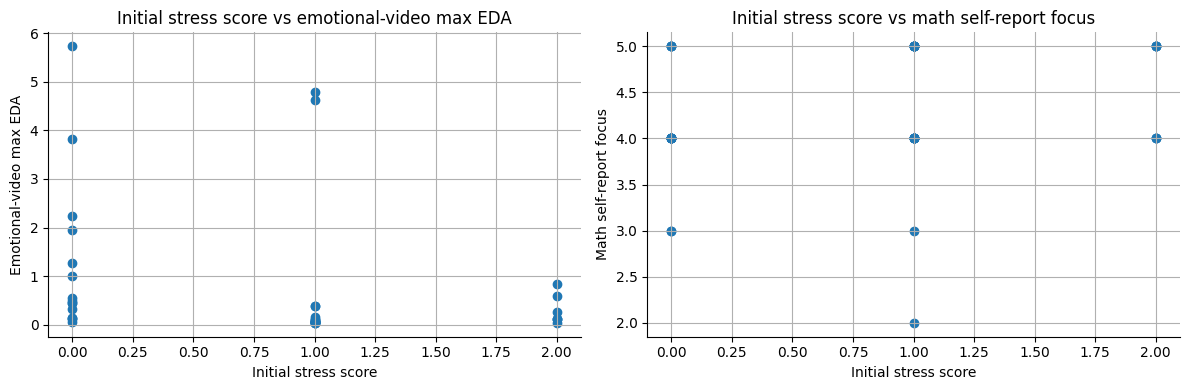

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(subject["stress_score"], subject["emo_EDA_max"])
axes[0].set_title("Initial stress score vs emotional-video max EDA")
axes[0].set_xlabel("Initial stress score")
axes[0].set_ylabel("Emotional-video max EDA")

axes[1].scatter(subject["stress_score"], subject["math_focus"])
axes[1].set_title("Initial stress score vs math self-report focus")
axes[1].set_xlabel("Initial stress score")
axes[1].set_ylabel("Math self-report focus")

plt.tight_layout()
plt.show()



## 6. Initial vs final meditation: do groups converge?

This section compares **2.1 Initial meditation** with **8.1 Final meditation**.

Questions:

- Do the initially stressed participants move toward the non-stressed group by the end?
- Or do differences remain visible?

Analyses:
- **Within-group paired comparison**: Wilcoxon signed-rank
- **Between-group comparison at final meditation**: Mann-Whitney U


In [13]:

def wilcoxon_summary(df_subject, metric_init, metric_final, group_name):
    temp = df_subject.loc[df_subject["stress_binary"] == group_name, [metric_init, metric_final]].dropna()
    stat, p = wilcoxon(temp[metric_init], temp[metric_final])
    return pd.Series({
        "group": group_name,
        "n": len(temp),
        "mean_initial": temp[metric_init].mean(),
        "mean_final": temp[metric_final].mean(),
        "median_initial": temp[metric_init].median(),
        "median_final": temp[metric_final].median(),
        "W": stat,
        "p_value": p,
    })

within_group_change = pd.concat([
    wilcoxon_summary(subject, "init_EDA_mean", "final_EDA_mean", "Not stressed"),
    wilcoxon_summary(subject, "init_EDA_mean", "final_EDA_mean", "Any pre-experiment stress"),
    wilcoxon_summary(subject, "init_Alpha_mean", "final_Alpha_mean", "Not stressed"),
    wilcoxon_summary(subject, "init_Alpha_mean", "final_Alpha_mean", "Any pre-experiment stress"),
], axis=1).T

within_group_change.round(4)


,group,n,mean_initial,mean_final,median_initial,median_final,W,p_value
0,Not stressed,15,1.268657,1.375822,0.440206,0.999189,39.0,0.25238
1,Any pre-experiment stress,24,0.48296,0.854882,0.084285,0.093916,118.0,0.37475
2,Not stressed,15,0.578869,0.62113,0.593181,0.593155,51.0,0.638672
3,Any pre-experiment stress,25,0.550512,0.561394,0.55426,0.584397,119.0,0.252104


In [14]:

final_group_tests = pd.DataFrame({
    "Final meditation EDA mean": mannwhitney_summary(subject, "final_EDA_mean"),
    "Final meditation Alpha mean": mannwhitney_summary(subject, "final_Alpha_mean"),
    "Final meditation BVP mean (exploratory)": mannwhitney_summary(subject, "final_BVP_mean"),
}).T

final_group_tests.round(4)


,group1,group2,n_group1,n_group2,mean_group1,median_group1,mean_group2,median_group2,U,p_value
Final meditation EDA mean,Not stressed,Any pre-experiment stress,15,24,1.375822,0.999189,0.854882,0.093916,289.0,0.001735
Final meditation Alpha mean,Not stressed,Any pre-experiment stress,15,25,0.62113,0.593155,0.561394,0.584397,203.0,0.675174
Final meditation BVP mean (exploratory),Not stressed,Any pre-experiment stress,15,24,-0.000016,0.000036,0.000009,0.000003,203.0,0.516003


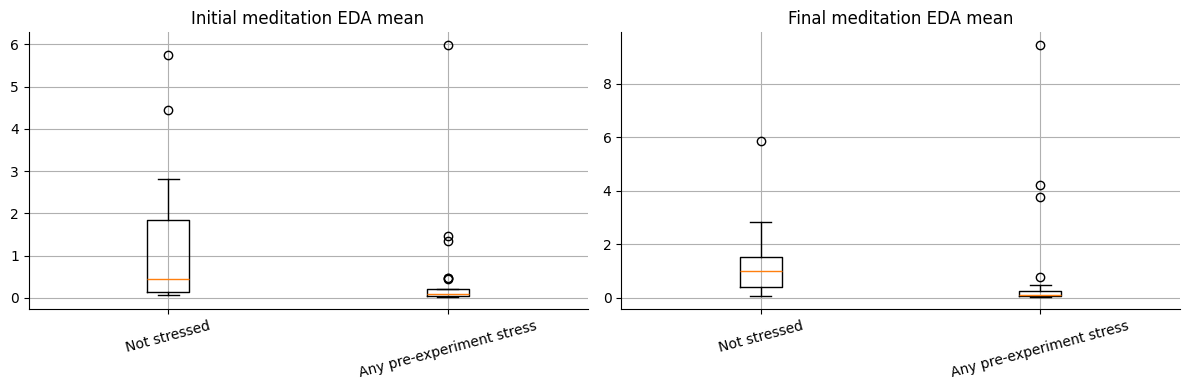

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(
    axes,
    ["init_EDA_mean", "final_EDA_mean"],
    ["Initial meditation EDA mean", "Final meditation EDA mean"],
):
    data_to_plot = [
        subject.loc[subject["stress_binary"] == "Not stressed", metric].dropna().values,
        subject.loc[subject["stress_binary"] == "Any pre-experiment stress", metric].dropna().values,
    ]
    ax.boxplot(data_to_plot, labels=["Not stressed", "Any pre-experiment stress"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()



## 7. Does baseline normalization change the story?

This is the practical issue behind the phenomenon.

If raw emotional reactivity differs across groups, but that difference disappears after subtracting each participant's own initial-meditation baseline, then the interpretation changes:

- the raw difference may largely reflect **different starting points**
- baseline normalization becomes analytically important

Here, a simple within-participant EDA normalization is computed as:

`emotional-video max EDA - initial-meditation mean EDA`


In [16]:

subject["emo_minus_init_EDA"] = subject["emo_EDA_max"] - subject["init_EDA_mean"]

normalization_comparison = pd.DataFrame({
    "Raw emotional-video max EDA": mannwhitney_summary(subject, "emo_EDA_max"),
    "Baseline-adjusted emotional EDA (emo max - init mean)": mannwhitney_summary(subject, "emo_minus_init_EDA"),
}).T

normalization_comparison.round(4)


,group1,group2,n_group1,n_group2,mean_group1,median_group1,mean_group2,median_group2,U,p_value
Raw emotional-video max EDA,Not stressed,Any pre-experiment stress,15,25,1.247865,0.497024,0.529329,0.103572,301.0,0.001595
Baseline-adjusted emotional EDA (emo max - init mean),Not stressed,Any pre-experiment stress,15,25,-0.020791,0.022711,0.05957,0.007742,211.0,0.520512


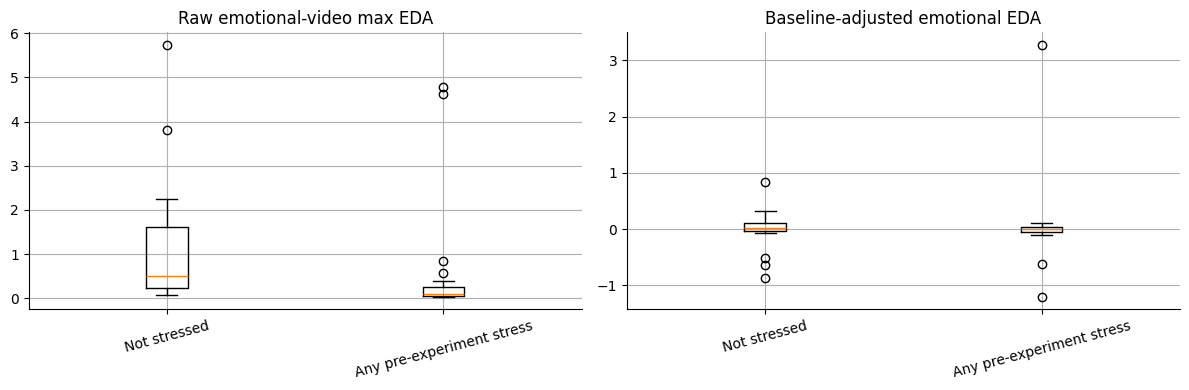

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(
    axes,
    ["emo_EDA_max", "emo_minus_init_EDA"],
    ["Raw emotional-video max EDA", "Baseline-adjusted emotional EDA"],
):
    data_to_plot = [
        subject.loc[subject["stress_binary"] == "Not stressed", metric].dropna().values,
        subject.loc[subject["stress_binary"] == "Any pre-experiment stress", metric].dropna().values,
    ]
    ax.boxplot(data_to_plot, labels=["Not stressed", "Any pre-experiment stress"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()



## 8. Text summary of the main findings


In [18]:

def p_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "< .001"
    return f"= {p:.3f}"

baseline_eda_p = baseline_tests.loc["Initial meditation EDA mean", "p_value"]
baseline_alpha_p = baseline_tests.loc["Initial meditation Alpha mean", "p_value"]
emo_corr_p = corr_results.loc["Stress score vs emotional-video max EDA", "p_value"]
math_corr_p = corr_results.loc["Stress score vs math self-report arousal", "p_value"]
final_eda_p = final_group_tests.loc["Final meditation EDA mean", "p_value"]
raw_emo_p = normalization_comparison.loc["Raw emotional-video max EDA", "p_value"]
adj_emo_p = normalization_comparison.loc["Baseline-adjusted emotional EDA (emo max - init mean)", "p_value"]

summary_lines = [
    f"1. Initial meditation EDA differed by baseline stress group (p {p_text(baseline_eda_p)}), indicating baseline heterogeneity.",
    f"2. Initial meditation alpha did not show a clear group difference (p {p_text(baseline_alpha_p)}).",
    f"3. Higher pre-experiment stress was associated with lower maximum EDA during the emotional video (Spearman p {p_text(emo_corr_p)}).",
    f"4. Initial stress did not clearly predict the math self-report arousal proxy (p {p_text(math_corr_p)}).",
    f"5. The EDA group difference was still present during final meditation (p {p_text(final_eda_p)}), so full convergence was not evident.",
    f"6. Raw emotional-video EDA differed by group (p {p_text(raw_emo_p)}), but the difference was not clear after baseline adjustment (p {p_text(adj_emo_p)}).",
]

for line in summary_lines:
    print(line)


1. Initial meditation EDA differed by baseline stress group (p = 0.006), indicating baseline heterogeneity.
2. Initial meditation alpha did not show a clear group difference (p = 0.386).
3. Higher pre-experiment stress was associated with lower maximum EDA during the emotional video (Spearman p = 0.011).
4. Initial stress did not clearly predict the math self-report arousal proxy (p = 0.626).
5. The EDA group difference was still present during final meditation (p = 0.002), so full convergence was not evident.
6. Raw emotional-video EDA differed by group (p = 0.002), but the difference was not clear after baseline adjustment (p = 0.521).



## 9. Conclusions

### Main conclusion

The dataset shows evidence of baseline heterogeneity. Participants who arrived with some level of pre-experiment stress did not look identical to the non-stressed group during the initial meditation, especially in EDA.

### Implications

1. **Baseline differences can confound later raw comparisons**  
   If participants start from different physiological states, a later raw difference may partly reflect that initial offset instead of a pure task effect.

2. **Intra-participant normalization is likely important**  
   In this dataset, a raw group difference in emotional-video EDA becomes much weaker after subtracting each participant's own initial-meditation baseline.  
   This supports the need for **within-participant normalization**.

3. **A one-size-fits-all analysis is risky**  
   Treating all participants as if they shared the same baseline may obscure real patterns or create misleading group contrasts.

4. **Recovery was incomplete**  
   The initially stressed group did not clearly converge to the non-stressed group by the final meditation on EDA, suggesting that the initial state may remain relevant across the session.

### Limitations

- The highest stress category is very small, so the binary grouping is more stable than a four-level inferential comparison.

